## RQ2 — Incumbency, Governing Party, and Positive Rhetoric
## *Words in Power, Words in Opposition* — ENSAE NLP Project 2026
### Author: Salma El-Aazdoudi

---
Incumbency vs. Governing Party: Local and National Effects

Legislative elections operate on two levels: local and national. Candidates run in individual constituencies, relying on their personal record, whether as incumbents or challengers. At the same time, the vote reflects a broader national judgment on the government, with voters choosing between the majority and the opposition.

**RQ2a — Individual mandate** asks whether incumbents use more positive language than challengers. This reflects the local dimension: does being in office shape how candidates present themselves to voters in their constituency?

**RQ2b — Governing party** asks whether candidates from the party in power use more positive language than those in the opposition. This reflects the national dimension: does defending or criticizing the government affect the tone of campaign messages?

Keeping these dimensions separate helps us see whether more positive rhetoric comes from personal experience, political position, or both.

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("df_full_merged.csv")

# ── Variable incumbent ────────────────────────────────────────────────────
def is_incumbent(mandat_str):
    if pd.isna(mandat_str):
        return 0
    s = str(mandat_str).strip().lower()
    if s in ["non mentionné", "aucun", "", "nan"]:
        return 0
    return 1

df["incumbent"] = df["titulaire-mandat-en-cours"].apply(is_incumbent)

print(df["incumbent"].value_counts())
print(f"\nIncumbent rate: {df['incumbent'].mean()*100:.1f}%")

BLOC_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]
INC_COLORS  = {"incumbent": "#2980b9", "opposition": "#e74c3c"}

sns.set_theme(style="whitegrid", font_scale=1.1)

# ── Score de positivité composite ─────────────────────────────────────────
pos_cols = ["tr_joy", "tr_gratitude", "tr_hope", "tr_pride"]
df["tr_positivity"] = df[pos_cols].mean(axis=1)

print(f"\nCorrelation joy vs composite: {df['tr_joy'].corr(df['tr_positivity']):.3f}")
print(df[["tr_joy", "tr_positivity"]].describe().round(3))

incumbent
0    3555
1    2891
Name: count, dtype: int64

Incumbent rate: 44.8%

Correlation joy vs composite: 0.915
         tr_joy  tr_positivity
count  6446.000       6446.000
mean      0.405          0.448
std       0.131          0.095
min       0.001          0.017
25%       0.301          0.381
50%       0.395          0.444
75%       0.508          0.514
max       0.759          0.718


# Part 1 : Positivity and Incumbency

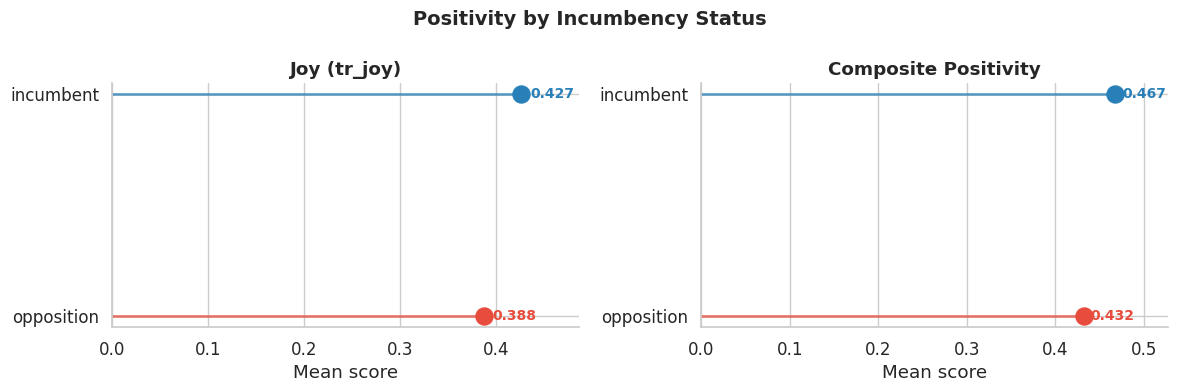

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Positivity by Incumbency Status", fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes, [("tr_joy", "Joy (tr_joy)"),
                                    ("tr_positivity", "Composite Positivity")]):
    stats = (
        df.groupby("incumbent")[col]
        .agg(["mean", "std", "count"])
    ).reset_index()
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["incumbent"].map({0: "opposition", 1: "incumbent"})
    colors = ["#e74c3c", "#2980b9"]

    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        # Tige horizontale
        ax.plot([0, row["mean"]], [row["label"], row["label"]],
                color=color, linewidth=2, alpha=0.7)
        # Cercle
        ax.scatter(row["mean"], row["label"],
                   color=color, s=150, zorder=5)
        # IC horizontal
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["label"], row["label"]],
                color=color, linewidth=3, alpha=0.4)
        # Annotation
        ax.text(row["mean"] + row["ci95"] + 0.005, row["label"],
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Mean score")
    ax.set_ylabel("")
    ax.set_xlim(0, stats["mean"].max() + 0.06)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("RQ2_lollipop_incumbency.png", dpi=150, bbox_inches="tight")
plt.show()

Incumbents score higher on both positivity measures than opposition candidates. 
Mean joy is 0.43 for incumbents versus 0.39 for opposition, and the composite 
positivity score shows the same gap (0.46 vs 0.43).

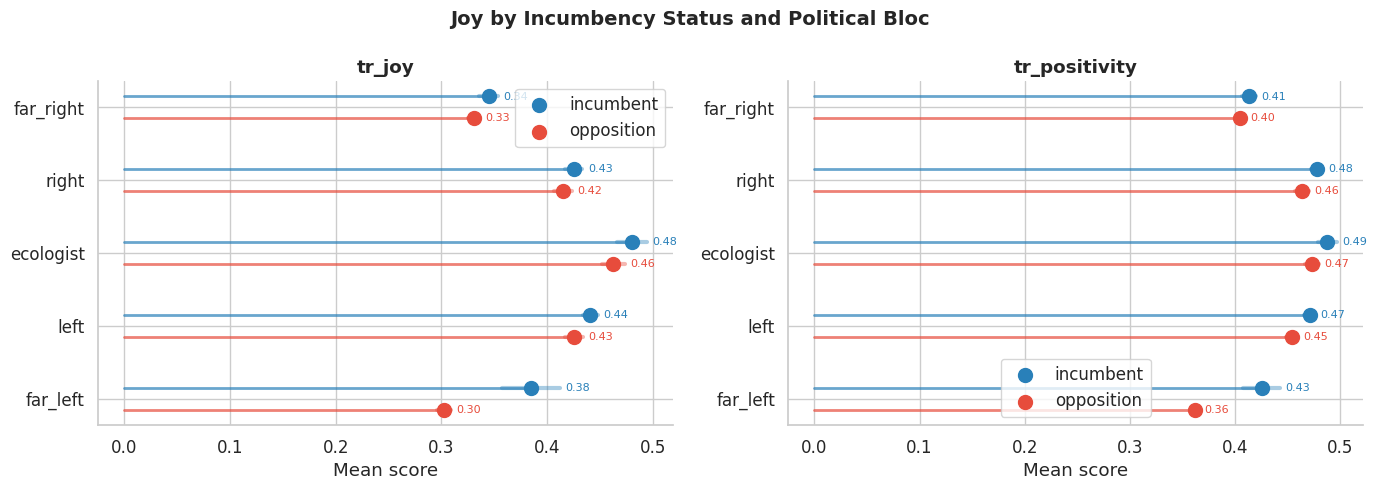

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Joy by Incumbency Status and Political Bloc",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["tr_joy", "tr_positivity"]):
    stats = (
        df.groupby(["bloc", "incumbent"])[col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["bloc"] = pd.Categorical(stats["bloc"],
                                   categories=BLOC_ORDER, ordered=True)
    stats = stats.sort_values("bloc").reset_index(drop=True)

    # Position verticale : un bloc par ligne, incumbent/opposition décalés
    y_positions = {bloc: i for i, bloc in enumerate(BLOC_ORDER)}
    offset = 0.15

    for inc_val, color, label in [(1, "#2980b9", "incumbent"),
                                   (0, "#e74c3c", "opposition")]:
        sub = stats[stats["incumbent"] == inc_val].reset_index(drop=True)
        for _, row in sub.iterrows():
            y = y_positions[row["bloc"]] + (offset if inc_val == 1 else -offset)
            # Tige
            ax.plot([0, row["mean"]], [y, y],
                    color=color, linewidth=2, alpha=0.7)
            # Cercle
            ax.scatter(row["mean"], y,
                       color=color, s=100, zorder=5,
                       label=label if _ == sub.index[0] else "")
            # IC
            ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                    [y, y], color=color, linewidth=3, alpha=0.4)
            # Annotation
            ax.text(row["mean"] + row["ci95"] + 0.005, y,
                    f'{row["mean"]:.2f}', va="center",
                    fontsize=8, color=color)

    ax.set_yticks(range(len(BLOC_ORDER)))
    ax.set_yticklabels(BLOC_ORDER)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Mean score")
    ax.spines[["top", "right"]].set_visible(False)

    # Légende sans doublons
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.savefig("RQ2_lollipop_bloc_incumbency.png", dpi=150, bbox_inches="tight")
plt.show()

The incumbency gap is visible across all blocs: incumbent candidates score higher 
on joy and composite positivity than opposition candidates within every ideological 
group. The pattern is consistent on both measures.

The gap is largest in the far-left, where incumbents score notably higher on joy 
(~0.44 vs ~0.30) — suggesting that far-left candidates with a record to defend 
adopt a markedly different tone than challengers. The gap is smallest in the 
mainstream left and ecologists, where incumbent and opposition scores are close.

Far-right candidates score lowest on joy overall, regardless of incumbency status — 
consistent with the RQ1 finding that negative affect dominates far-right rhetoric.

In [5]:
# ── 3. OLS principal ──────────────────────────────────────────────────────
print("=" * 65)
print("OLS — incumbent predicts joy and positivity")
print("controlling for bloc and year")
print("=" * 65)

for col, label in [("tr_joy", "Joy"), ("tr_positivity", "Composite Positivity")]:
    model = smf.ols(
        f"{col} ~ C(incumbent) + C(bloc, Treatment('left')) + C(year_dummy)",
        data=df.dropna(subset=[col, "incumbent", "bloc", "year_dummy"])
    ).fit()
    print(f"\n── {label} — R²={model.rsquared:.4f} | N={int(model.nobs):,} ──")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "incumbent" in name or "bloc" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:50} β={coef:+.4f}  p={pval:.4f}  {stars}")

OLS — incumbent predicts joy and positivity
controlling for bloc and year

── Joy — R²=0.1960 | N=6,446 ──
  C(incumbent)[T.1]                                  β=+0.0187  p=0.0000  ***
  C(bloc, Treatment('left'))[T.ecologist]            β=+0.0693  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_left]             β=-0.1102  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_right]            β=-0.0643  p=0.0000  ***
  C(bloc, Treatment('left'))[T.right]                β=+0.0021  p=0.5696  n.s.

── Composite Positivity — R²=0.1854 | N=6,446 ──
  C(incumbent)[T.1]                                  β=+0.0179  p=0.0000  ***
  C(bloc, Treatment('left'))[T.ecologist]            β=+0.0345  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_left]             β=-0.0856  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_right]            β=-0.0366  p=0.0000  ***
  C(bloc, Treatment('left'))[T.right]                β=+0.0162  p=0.0000  ***


Controlling for ideological bloc and electoral year, incumbent candidates score 
significantly higher on both joy (β = +0.019, p < 0.001) and composite positivity 
(β = +0.018, p < 0.001). The incumbency effect is small but robust.

The bloc coefficients confirm the RQ1 pattern: far-left (β = −0.110) and far-right 
(β = −0.064) score significantly lower on joy than the mainstream left, while 
ecologists score higher (β = +0.069). The mainstream right is not significantly 
different from the left on joy alone, but scores slightly higher on composite 
positivity (β = +0.016).


In [6]:
# ── 4. OLS avec interaction incumbent × bloc ─────────────────────────────
print("=" * 65)
print("OLS — interaction incumbent × bloc")
print("=" * 65)

for col, label in [("tr_joy", "Joy"), ("tr_positivity", "Composite Positivity")]:
    model = smf.ols(
        f"{col} ~ C(incumbent) * C(bloc, Treatment('left')) + C(year_dummy)",
        data=df.dropna(subset=[col, "incumbent", "bloc", "year_dummy"])
    ).fit()
    print(f"\n── {label} — R²={model.rsquared:.4f} | N={int(model.nobs):,} ──")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "incumbent" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:60} β={coef:+.4f}  p={pval:.4f}  {stars}")

OLS — interaction incumbent × bloc

── Joy — R²=0.1979 | N=6,446 ──
  C(incumbent)[T.1]                                            β=+0.0129  p=0.0094  **
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.ecologist]    β=+0.0103  p=0.3589  n.s.
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.far_left]     β=+0.0677  p=0.0001  ***
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.far_right]    β=+0.0086  p=0.3834  n.s.
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.right]        β=+0.0039  p=0.5923  n.s.



── Composite Positivity — R²=0.1873 | N=6,446 ──
  C(incumbent)[T.1]                                            β=+0.0157  p=0.0000  ***
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.ecologist]    β=+0.0023  p=0.7832  n.s.
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.far_left]     β=+0.0473  p=0.0002  ***
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.far_right]    β=-0.0035  p=0.6314  n.s.
  C(incumbent)[T.1]:C(bloc, Treatment('left'))[T.right]        β=+0.0022  p=0.6842  n.s.


The interaction model reveals that the incumbency effect is not uniform across 
blocs. For most blocs — ecologist, right, far-right — the interaction terms are 
not significant, meaning incumbents and opposition candidates within those blocs 
use similar levels of positivity.

The exception is **far-left**: the interaction term is positive and significant on 
both joy (β = +0.068, p < 0.001) and composite positivity (β = +0.047, p < 0.001). 
Far-left incumbents are markedly more positive than far-left opposition candidates — 
a gap that does not exist in any other bloc.

This is substantively interesting: holding office appears to moderate the emotional 
register of far-left candidates specifically, pulling them toward a more positive 
tone. For the mainstream left, right, ecologists and far-right, incumbency adds a 
small uniform positive effect but does not fundamentally change the rhetorical 
register.

In [7]:
# ── 5. Sensitivity : par année ────────────────────────────────────────────
print("=" * 65)
print("SENSITIVITY — OLS by year")
print("=" * 65)

for year in [1981, 1993]:
    df_year = df[df["year"] == year].copy()
    print(f"\n── YEAR {year} — N={len(df_year):,} ──")
    model = smf.ols(
        "tr_joy ~ C(incumbent) + C(bloc, Treatment('left'))",
        data=df_year.dropna(subset=["tr_joy", "incumbent", "bloc"])
    ).fit()
    print(f"  R² = {model.rsquared:.4f}")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "incumbent" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:50} β={coef:+.4f}  p={pval:.4f}  {stars}")

SENSITIVITY — OLS by year

── YEAR 1981 — N=2,388 ──
  R² = 0.2380
  C(incumbent)[T.1]                                  β=+0.0083  p=0.1139  n.s.

── YEAR 1993 — N=4,058 ──
  R² = 0.2562
  C(incumbent)[T.1]                                  β=+0.0131  p=0.0003  ***


The incumbency effect is driven entirely by 1993. In 1981, the coefficient is 
positive but not significant (β = +0.008, p = 0.11). In 1993, it is significant 
and of similar magnitude (β = +0.013, p < 0.001).

This is not surprising: in 1981, the political context was unusual — Mitterrand had 
just won the presidency, and the left was running as both an incumbent force and a 
movement of change. The distinction between incumbent and opposition was less 
meaningful rhetorically. By 1993, with the Socialist government defending a record 
amid economic crisis, the incumbent/opposition divide maps more cleanly onto 
positive versus negative rhetoric.

# Part 2 : Governing Party and Emotional Tone

In [5]:
df["parti_au_pouvoir"] = (
    ((df["year"] == 1981) & (df["bloc"] == "left")) |
    ((df["year"] == 1993) & (df["bloc"] == "right"))
).astype(int)

print(df["parti_au_pouvoir"].value_counts())
print(f"\nRate: {df['parti_au_pouvoir'].mean()*100:.1f}%")
print(df.groupby(["year", "bloc"])["parti_au_pouvoir"].mean())

parti_au_pouvoir
0    3855
1    2591
Name: count, dtype: int64

Rate: 40.2%
year  bloc     
1981  ecologist    0.0
      far_left     0.0
      far_right    0.0
      left         1.0
      right        0.0
1993  ecologist    0.0
      far_left     0.0
      far_right    0.0
      left         0.0
      right        1.0
Name: parti_au_pouvoir, dtype: float64


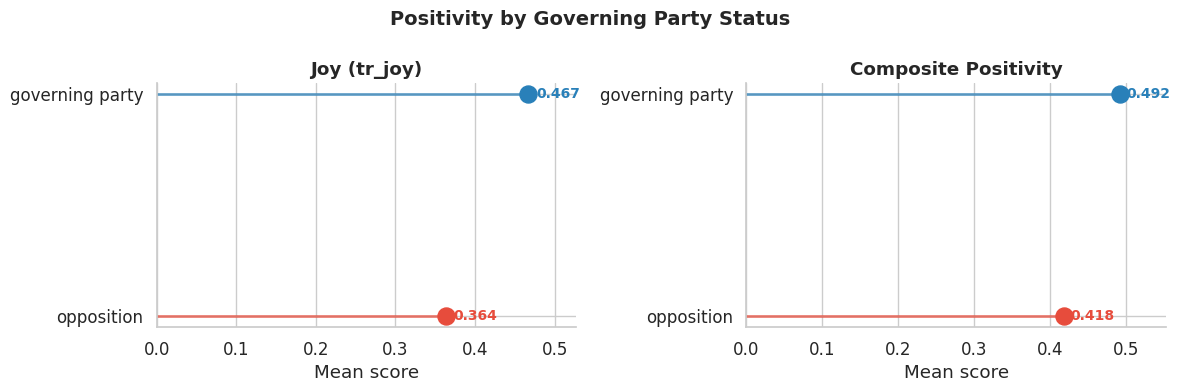

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Positivity by Governing Party Status", fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes, [("tr_joy", "Joy (tr_joy)"),
                                    ("tr_positivity", "Composite Positivity")]):
    stats = (
        df.groupby("parti_au_pouvoir")[col]
        .agg(["mean", "std", "count"])
    ).reset_index()
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["parti_au_pouvoir"].map({0: "opposition", 1: "governing party"})
    colors = ["#e74c3c", "#2980b9"]

    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        # Tige horizontale
        ax.plot([0, row["mean"]], [row["label"], row["label"]],
                color=color, linewidth=2, alpha=0.7)
        # Cercle
        ax.scatter(row["mean"], row["label"],
                   color=color, s=150, zorder=5)
        # IC horizontal
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["label"], row["label"]],
                color=color, linewidth=3, alpha=0.4)
        # Annotation
        ax.text(row["mean"] + row["ci95"] + 0.005, row["label"],
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Mean score")
    ax.set_ylabel("")
    ax.set_xlim(0, stats["mean"].max() + 0.06)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("RQ2b_lollipop_governing.png", dpi=150, bbox_inches="tight")
plt.show()

Candidates from the governing party score notably higher on both positivity 
measures than opposition candidates — mean joy 0.46 vs 0.37, a gap of nearly 
10 points. This is substantially larger than the individual incumbency effect 
(4 points), suggesting that collective political context matters more than personal 
mandate status.

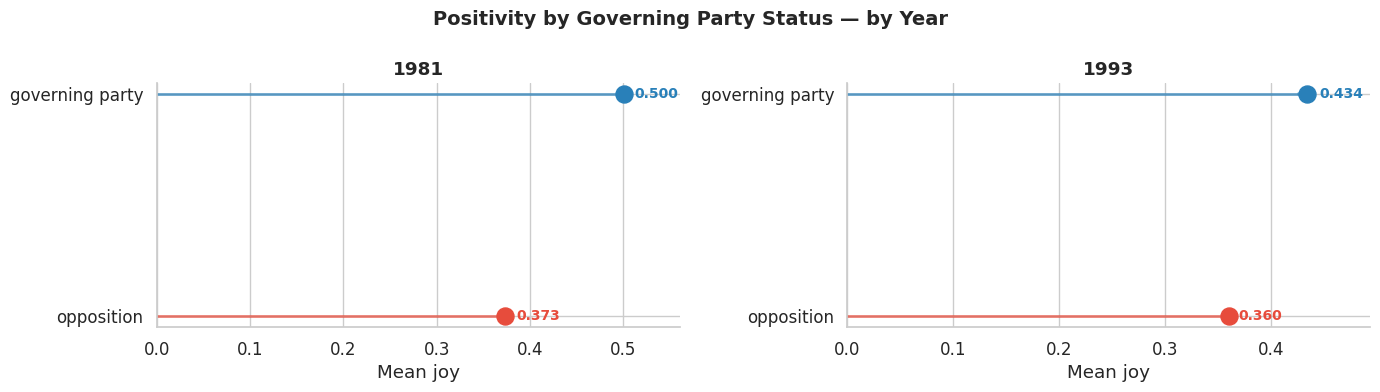

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Positivity by Governing Party Status — by Year",
             fontsize=14, fontweight="bold")

for ax, year in zip(axes, [1981, 1993]):
    df_year = df[df["year"] == year]
    stats = (
        df_year.groupby("parti_au_pouvoir")["tr_joy"]
        .agg(["mean", "std", "count"])
    ).reset_index()
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["parti_au_pouvoir"].map({0: "opposition", 1: "governing party"})
    colors = ["#e74c3c", "#2980b9"]

    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        # Tige horizontale
        ax.plot([0, row["mean"]], [row["label"], row["label"]],
                color=color, linewidth=2, alpha=0.7)
        # Cercle
        ax.scatter(row["mean"], row["label"],
                   color=color, s=150, zorder=5)
        # IC horizontal
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["label"], row["label"]],
                color=color, linewidth=3, alpha=0.4)
        # Annotation
        ax.text(row["mean"] + row["ci95"] + 0.005, row["label"],
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(f"{year}", fontweight="bold")
    ax.set_xlabel("Mean joy")
    ax.set_ylabel("")
    ax.set_xlim(0, stats["mean"].max() + 0.06)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("RQ2b_lollipop_year.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── 3. OLS principal ──────────────────────────────────────────────────────
print("=" * 65)
print("OLS — governing party predicts joy and positivity")
print("=" * 65)

for col, label in [("tr_joy", "Joy"), ("tr_positivity", "Composite Positivity")]:
    model = smf.ols(
        f"{col} ~ C(parti_au_pouvoir) + C(year_dummy)",
        data=df.dropna(subset=[col, "parti_au_pouvoir", "year_dummy"])
    ).fit()
    print(f"\n── {label} — R²={model.rsquared:.4f} | N={int(model.nobs):,} ──")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "parti" in name or "year" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:50} β={coef:+.4f}  p={pval:.4f}  {stars}")


OLS — governing party predicts joy and positivity

── Joy — R²=0.1671 | N=6,446 ──
  C(parti_au_pouvoir)[T.1]                           β=+0.0953  p=0.0000  ***
  C(year_dummy)[T.1]                                 β=-0.0374  p=0.0000  ***

── Composite Positivity — R²=0.1487 | N=6,446 ──
  C(parti_au_pouvoir)[T.1]                           β=+0.0706  p=0.0000  ***
  C(year_dummy)[T.1]                                 β=-0.0137  p=0.0000  ***


Governing party candidates score 9.5 points higher on joy (β = +0.095, p < 0.001) 
and 7.1 points higher on composite positivity (β = +0.071, p < 0.001) than 
opposition candidates, controlling for electoral year. This is five times larger 
than the individual incumbency effect.

The year dummy is negative and significant, indicating that positivity was 
generally lower in 1993 than in 1981 (consistent with the more difficult 
political and economic context of that election).

In [9]:
# ── 4. OLS avec contrôle sur les blocs au pouvoir uniquement ─────────────
# Comparer left 1981 vs right 1993 directement
print("\n" + "=" * 65)
print("OLS — governing party vs opposition WITHIN governing blocs")
print("(left in 1981, right in 1993 only)")
print("=" * 65)

df_gov_blocs = df[
    ((df["year"] == 1981) & (df["bloc"].isin(["left", "right"]))) |
    ((df["year"] == 1993) & (df["bloc"].isin(["left", "right"])))
].copy()

for col, label in [("tr_joy", "Joy"), ("tr_positivity", "Composite Positivity")]:
    model = smf.ols(
        f"{col} ~ C(parti_au_pouvoir) + C(year_dummy)",
        data=df_gov_blocs.dropna(subset=[col, "parti_au_pouvoir", "year_dummy"])
    ).fit()
    print(f"\n── {label} — R²={model.rsquared:.4f} | N={int(model.nobs):,} ──")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
        print(f"  {name:50} β={coef:+.4f}  p={pval:.4f}  {stars}")


OLS — governing party vs opposition WITHIN governing blocs
(left in 1981, right in 1993 only)

── Joy — R²=0.1776 | N=4,225 ──
  Intercept                                          β=+0.4018  p=0.0000  ***
  C(parti_au_pouvoir)[T.1]                           β=+0.0938  p=0.0000  ***
  C(year_dummy)[T.1]                                 β=-0.0570  p=0.0000  ***

── Composite Positivity — R²=0.1158 | N=4,225 ──
  Intercept                                          β=+0.4423  p=0.0000  ***
  C(parti_au_pouvoir)[T.1]                           β=+0.0612  p=0.0000  ***
  C(year_dummy)[T.1]                                 β=-0.0231  p=0.0000  ***


The within-governing-blocs model (left in 1981, right in 1993 only) confirms 
the result: even when restricting to the two blocs that actually alternated in 
power, the governing party effect holds (β = +0.094, p < 0.001).

In [10]:
# ── 5. Sensitivity : par année ────────────────────────────────────────────
print("\n" + "=" * 65)
print("SENSITIVITY — OLS by year")
print("=" * 65)

for year in [1981, 1993]:
    df_year = df[df["year"] == year].copy()
    print(f"\n── YEAR {year} — N={len(df_year):,} ──")
    model = smf.ols(
        "tr_joy ~ C(parti_au_pouvoir)",
        data=df_year.dropna(subset=["tr_joy", "parti_au_pouvoir"])
    ).fit()
    print(f"  R² = {model.rsquared:.4f}")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "parti" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:50} β={coef:+.4f}  p={pval:.4f}  {stars}")


SENSITIVITY — OLS by year

── YEAR 1981 — N=2,388 ──
  R² = 0.2250
  C(parti_au_pouvoir)[T.1]                           β=+0.1270  p=0.0000  ***

── YEAR 1993 — N=4,058 ──
  R² = 0.0759
  C(parti_au_pouvoir)[T.1]                           β=+0.0739  p=0.0000  ***


The effect holds in both years but is stronger in 1981 (β = +0.127) than in 
1993 (β = +0.074). In 1981, the Socialist party had just won power after years 
in opposition — the contrast between governing optimism and opposition frustration 
was likely at its sharpest. By 1993, the RPR/UDF were returning to power in a 
context of economic crisis, which may have moderated the positivity of their 
rhetoric.

## Conclusion

Both dimensions of incumbency predict positivity, but the governing party effect 
is substantially stronger. Having a personal mandate adds about 2 points to joy 
scores; belonging to the governing party adds nearly 10 points. Collective 
political positioning — defending or attacking the government — shapes electoral 
rhetoric more than individual record.

The one exception is the far-left, where individual incumbency has a large 
moderating effect: far-left incumbents sound markedly more positive than 
far-left challengers. This suggests that institutional responsibility pulls 
far-left candidates toward a more measured tone regardless of the national 
political context.

The sensitivity analysis shows that both effects are concentrated in 1993, 
when the political and economic stakes were higher and the incumbent/opposition 
divide mapped more cleanly onto rhetorical register.